# Fitting scores with a Potts (pairwise) model

### Extension of the linear model: recover both single-site weights $F$ and pairwise couplings $J$

In the linear (profile) model the score of a sequence $s = (a_0, \dots, a_{L-1})$ is

$$
E^{\text{lin}}(s) = \sum_{i=0}^{L-1} F[a_i, i]
$$

The **Potts model** adds pairwise interaction terms:

$$
E^{\text{Potts}}(s) = \sum_{i} F[a_i,\, i] + \sum_{i < j} J[i,\, j,\, a_i,\, a_j]
$$

where $J \in \mathbb{R}^{L \times L \times A \times A}$ is a symmetric coupling tensor ($J[i,j] = J[j,i]^\top$).  
The regression task is then to recover both $F$ and $J$ from the observed read counts $(n_0, \lambda_1', n_2)$.


In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

from First_modelization.sequence_classes import (
    sample_sequences, produce_capsids, ngs_simple, protocol,
    T_sel, T_viab, rho, alpha, epsilon, D, N_pcr, N1,
)
from analysis import pearson, precision_at_k


## 1. Sequence library and Potts ground-truth model

We use the same library as the linear notebooks: $10^6$ sequences of length $L=7$ over $A=20$ amino acids.  
The GT model has:
- **$F_{\text{GT}}$** (20 × 7): single-site weights — identical rules to the linear model.
- **$J_{\text{GT}}$** (7 × 7 × 20 × 20): sparse pairwise couplings; most entries are zero.

The sparsity makes recovery tractable and lets us visually verify which couplings are recovered.


In [3]:
key = jax.random.key(42)
key_seq, key_viab_w, key_sel_w, key_n0, key_run = jax.random.split(key, 5)

num_sequences   = 1_000_000
num_positions   = 7      # L
num_amino_acids = 20     # A

sequences = jax.random.randint(
    key_seq, shape=(num_sequences, num_positions),
    minval=0, maxval=num_amino_acids,
)

# Initial read counts: uniform + small noise
n0 = jax.random.poisson(key_n0, jnp.ones(num_sequences) * 10.0).astype(jnp.float32)
print(f"sequences : {sequences.shape}  dtype={sequences.dtype}")
print(f"n0        : {n0.shape}  mean={float(n0.mean()):.1f}  non-zero={int(jnp.sum(n0>0))}")


sequences : (1000000, 7)  dtype=int32
n0        : (1000000,)  mean=10.0  non-zero=999955


### 1.1 Single-site weights $F_{\text{GT}}$

Same construction as the linear notebooks so we can compare Potts vs linear recovery.


In [4]:
# ── Viability single-site weights F_viab_GT (A × L) ─────────────────────────
F_viab_GT = np.zeros((num_amino_acids, num_positions))
F_viab_GT[0::2, :] += 0.5                        # Rule 1: even AAs preferred
for i in range(num_positions):
    F_viab_GT[i, i] += 1.0                        # Rule 2: diagonal affinity
F_viab_GT[15:20, 3:6] -= 1.0                     # Rule 3: AAs 15-19 bad at positions 3-5
F_viab_GT = jnp.array(F_viab_GT)

# ── Selectivity single-site weights F_sel_GT (A × L) ─────────────────────────
F_sel_GT = np.zeros((num_amino_acids, num_positions))
F_sel_GT[15:20, :] += 0.5                         # Rule 1: AAs 15-19 preferred
F_sel_GT[5:10, 0]  += 0.7                         # Rule 2: AAs 5-9 at position 0
F_sel_GT[0:2, 4:6] += 1.2                         # Rule 3: AAs 0-1 at positions 4-5
F_sel_GT[10:15, :] -= 0.3                         # Rule 4: AAs 10-14 slightly penalised
F_sel_GT = jnp.array(F_sel_GT)

print("F_viab_GT :", F_viab_GT.shape, "  range:", float(F_viab_GT.min()), float(F_viab_GT.max()))
print("F_sel_GT  :", F_sel_GT.shape,  "  range:", float(F_sel_GT.min()),  float(F_sel_GT.max()))


F_viab_GT : (20, 7)   range: -1.0 1.5
F_sel_GT  : (20, 7)   range: -0.30000001192092896 1.2000000476837158


### 1.2 Pairwise couplings $J_{\text{GT}}$

We define a **sparse** coupling tensor with a handful of non-zero interactions.  
Symmetry is enforced: $J[i,j,a,b] = J[j,i,b,a]$.


In [5]:
L, A = num_positions, num_amino_acids

def make_J(interactions):
    """
    Build a symmetric (L, L, A, A) coupling tensor from a list of
    (i, j, a, b, value) entries.  Both (i,j,a,b) and (j,i,b,a) are set.
    """
    J = np.zeros((L, L, A, A))
    for (i, j, a, b, v) in interactions:
        J[i, j, a, b] += v
        J[j, i, b, a] += v
    return jnp.array(J)

# Viability pairwise couplings
J_viab_GT = make_J([
    (0, 1,  0,  0,  2.0),   # AA0@pos0 + AA0@pos1 strongly cooperate
    (2, 4,  5,  5,  1.5),   # AA5@pos2 + AA5@pos4 cooperate
    (1, 3, 10, 10, -1.5),   # AA10@pos1 + AA10@pos3 clash
    (0, 6,  2,  2,  1.0),   # AA2 at N- and C-terminus cooperate
])

# Selectivity pairwise couplings
J_sel_GT = make_J([
    (0, 6, 15, 15,  2.0),   # AA15 at N-term + C-term cooperate
    (2, 3,  0,  1, -1.0),   # AA0@pos2 + AA1@pos3 clash
    (1, 5, 17, 17,  1.2),   # AA17@pos1 + AA17@pos5 cooperate
    (3, 4,  8,  8, -0.8),   # AA8@pos3 + AA8@pos4 antagonise
])

print("J_viab_GT non-zero entries:", int(np.sum(np.array(J_viab_GT) != 0)))
print("J_sel_GT  non-zero entries:", int(np.sum(np.array(J_sel_GT) != 0)))


J_viab_GT non-zero entries: 8
J_sel_GT  non-zero entries: 8


## 2. Potts score function

$$
E^{\text{Potts}}(s) = \underbrace{\sum_{i} F[a_i, i]}_{\text{single-site}} + \underbrace{\sum_{i < j} J[i, j, a_i, a_j]}_{\text{pairwise}}
$$

The pairwise sum runs over $\binom{L}{2} = 21$ position pairs.


In [9]:
def calculate_potts_scores(seqs, F, J):
    """
    Potts score for each sequence.

    Parameters
    ----------
    seqs : (N, L) int array
    F    : (A, L) float array — single-site weights
    J    : (L, L, A, A) float array — pairwise couplings (symmetric)

    Returns
    -------
    (N,) float array
    """
    # Single-site term: sum_i F[a_i, i]
    scores = jnp.sum(F[seqs, jnp.arange(seqs.shape[1])], axis=1)

    # Pairwise term: sum_{i<j} J[i, j, a_i, a_j]
    for i in range(seqs.shape[1]):
        for j in range(i + 1, seqs.shape[1]):
            scores = scores + J[i, j, seqs[:, i], seqs[:, j]]

    return scores


viability   scores : min=-3.00  max=9.00
selectivity scores : min=-2.50  max=6.40


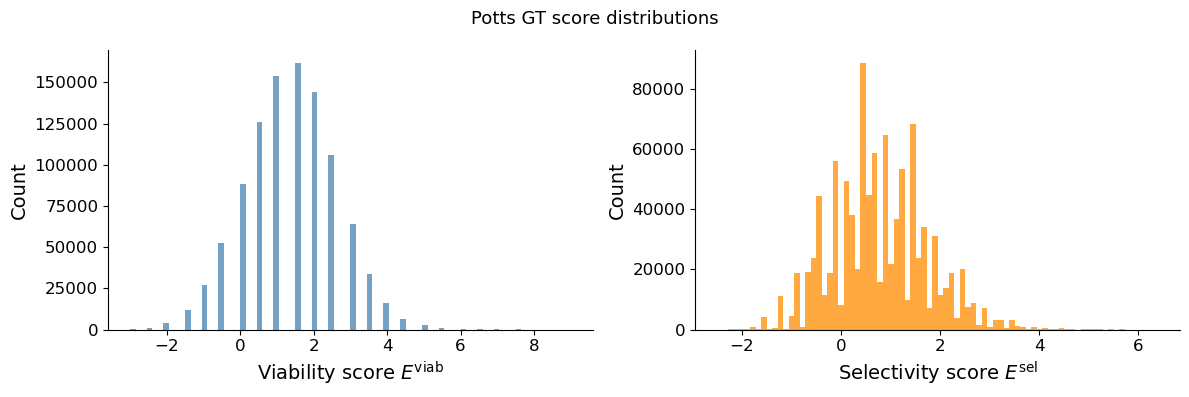

In [17]:
viability_scores_GT   = calculate_potts_scores(sequences, F_viab_GT, J_viab_GT)
selectivity_scores_GT = calculate_potts_scores(sequences, F_sel_GT,  J_sel_GT)

print(f"viability   scores : min={float(viability_scores_GT.min()):.2f}  max={float(viability_scores_GT.max()):.2f}")
print(f"selectivity scores : min={float(selectivity_scores_GT.min()):.2f}  max={float(selectivity_scores_GT.max()):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scores, label, color in [
    (axes[0], viability_scores_GT,   'Viability score $E^{\\mathrm{viab}}$',   'steelblue'),
    (axes[1], selectivity_scores_GT, 'Selectivity score $E^{\\mathrm{sel}}$', 'darkorange'),
]:
    ax.hist(np.array(scores), bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.set_xlabel(label, fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Potts GT score distributions', fontsize=13)
plt.tight_layout()
plt.show()


## 3. AAV selection protocol with Potts scores

We replicate the protocol steps from `sequence_classes.py` but inject the Potts scores directly,  
since the built-in `protocol()` function uses linear weights internally.

**Production phase**
1. Simple NGS on $n_0$ → $\lambda_0$
2. Sample $\lambda_0$ → $x_1$
3. Capsid production weighted by $E^{\mathrm{viab}}$ → capsids
4. NGS on capsids → $\lambda_1'$

**Selectivity phase**
5. Soft-max enrichment of $\lambda_1'$ by $E^{\mathrm{sel}}$ → $n_2$


In [18]:
key_prot = jax.random.key(99)
k1, k2, k3, k4, k5, k6 = jax.random.split(key_prot, 6)

# 1. NGS on n0
proportions0 = n0 / jnp.sum(n0)
lambda0 = jax.random.poisson(k1, proportions0 * D).astype(jnp.float32)

# 2. Sample
x1 = jax.random.poisson(k2, lambda0 / jnp.sum(lambda0) * N1).astype(jnp.float32)

# 3. Capsid production (viability)
capsids = produce_capsids(x1, viability_scores_GT, epsilon, alpha, rho, T_viab, k3).astype(jnp.float32)

# 4. NGS on capsids
proportions_cap = capsids / (jnp.sum(capsids) + 1e-9)
lambda1p = jax.random.poisson(k4, proportions_cap * D).astype(jnp.float32)

# 5. Selectivity
s_tilde     = selectivity_scores_GT + epsilon * jax.random.normal(k5, shape=selectivity_scores_GT.shape)
log_weights = s_tilde / T_sel - jnp.max(s_tilde / T_sel)
post_select = lambda1p * jnp.exp(log_weights)
n2          = jax.random.poisson(k6, post_select / jnp.sum(post_select) * D).astype(jnp.float32)

print(f"lambda0  non-zero: {int(jnp.sum(lambda0>0)):>7d}")
print(f"capsids  non-zero: {int(jnp.sum(capsids>0)):>7d}")
print(f"lambda1p non-zero: {int(jnp.sum(lambda1p>0)):>7d}")
print(f"n2       non-zero: {int(jnp.sum(n2>0)):>7d}")


lambda0  non-zero:   48371
capsids  non-zero:   24836
lambda1p non-zero:   14607
n2       non-zero:    5346


## 4. Log-ratio regression targets

Same as the linear model — we regress on the log-enrichment ratios:

$$
y^{\text{viab}}(s) = \log\frac{\lambda_1'(s) + \varepsilon}{\hat{n}_0(s) + \varepsilon}, \qquad
y^{\text{sel}}(s) = \log\frac{n_2(s) + \varepsilon}{\hat{\lambda}_1'(s) + \varepsilon}
$$

These approximate $E^{\text{viab}}/T_{\text{viab}}$ and $E^{\text{sel}}/T_{\text{sel}}$ up to additive constants.


In [19]:
eps = 0.5

n0_norm  = n0       / jnp.sum(n0)       * jnp.sum(lambda1p)
l1p_norm = lambda1p / jnp.sum(lambda1p) * jnp.sum(n2)

y_viab = jnp.log((lambda1p + eps) / (n0_norm + eps))
y_sel  = jnp.log((n2        + eps) / (l1p_norm + eps))

print(f"y_viab : min={float(y_viab.min()):.2f}  max={float(y_viab.max()):.2f}  mean={float(y_viab.mean()):.2f}")
print(f"y_sel  : min={float(y_sel.min()):.2f}  max={float(y_sel.max()):.2f}  mean={float(y_sel.mean()):.2f}")


y_viab : min=-0.26  max=6.02  mean=-0.07
y_sel  : min=-5.82  max=6.40  mean=-0.01


## 5. Pairwise feature encoding

The Potts score is linear in the one-hot pairwise features:

$$
E^{\text{Potts}}(s) = \sum_{i,a} F[a,i]\, \mathbf{1}[a_i=a] + \sum_{i<j}\sum_{a,b} J[i,j,a,b]\, \mathbf{1}[a_i=a]\, \mathbf{1}[a_j=b]
$$

We construct:
- **Single-site features** $X_1$: one-hot encoding → $L \times A = 140$ features per sequence
- **Pairwise features** $X_2$: outer product $\mathbf{1}[a_i=\cdot] \otimes \mathbf{1}[a_j=\cdot]$ for each pair $i<j$ → $\binom{L}{2} \times A^2 = 21 \times 400 = 8400$ features
- **Total** (with bias): $140 + 8400 + 1 = 8541$ features

We build $X$ only for **observed sequences** (those with $\lambda_1' > 0$ for viability, $n_2 > 0$ for selectivity) to keep memory manageable.


In [ ]:
def build_potts_features(seqs_obs, A=20):
    """
    Build the combined single-site + pairwise feature matrix.

    Parameters
    ----------
    seqs_obs : (N, L) int array — observed sequences (subset)
    A        : int — alphabet size

    Returns
    -------
    X : (N, L*A + L*(L-1)//2 * A**2 + 1) float32 numpy array
    """
    N, Lseq = seqs_obs.shape

    # One-hot: (N, L, A)
    oh = np.eye(A, dtype=np.float32)[np.array(seqs_obs)]  # (N, L, A)

    # Single-site features: (N, L*A)
    X1 = oh.reshape(N, -1)

    # Pairwise features
    pairs = []
    for i in range(Lseq):
        for j in range(i + 1, Lseq):
            pair_ij = oh[:, i, :, None] * oh[:, j, None, :]  # (N, A, A)
            pairs.append(pair_ij.reshape(N, A * A))

    X2 = np.concatenate(pairs, axis=1)  # (N, L*(L-1)/2 * A^2)

    bias = np.ones((N, 1), dtype=np.float32)
    return np.concatenate([X1, X2, bias], axis=1)

mask_viab = np.array(lambda1p > 0)
mask_sel  = np.array(n2 > 0)
print(f"Observed sequences — viability: {mask_viab.sum():>7d}  selectivity: {mask_sel.sum():>7d}")

print("Building pairwise features for viability subset...")
X_viab = build_potts_features(np.array(sequences[mask_viab]))
print(f"X_viab : {X_viab.shape}  ({X_viab.nbytes / 1e9:.2f} GB)")

print("Building pairwise features for selectivity subset...")
X_sel_feat = build_potts_features(np.array(sequences[mask_sel]))
print(f"X_sel  : {X_sel_feat.shape}  ({X_sel_feat.nbytes / 1e9:.2f} GB)")

Observed sequences — viability:   14607  selectivity:    5346
Building pairwise features for viability subset...
X_viab : (14607, 8541)  (0.50 GB)
Building pairwise features for selectivity subset...
X_sel  : (5346, 8541)  (0.18 GB)


## 6. Ridge regression for Potts

We reuse the same Ridge formulation as the linear notebook:

$$
\hat{\mathbf{w}} = (X^\top X + \lambda I)^{-1} X^\top \mathbf{y}
$$

with the larger $(8541 \times 8541)$ Gram matrix. The penalty $\lambda$ is chosen by 5-fold CV on MSE.

After fitting, we extract:
- $\hat{F}[a, i] = w_{140 \text{ single-site}} \cdot T$ (rescaled by temperature)
- $\hat{J}[i,j,a,b] = w_{\text{pairwise}} \cdot T$ (rescaled)


In [21]:
def ridge_cv_mse_potts(X, y, lambdas, kf):
    """5-fold CV MSE for Ridge regression on the Potts feature matrix."""
    mse = np.zeros(len(lambdas))
    n_feat = X.shape[1]
    for fold, (tr, va) in enumerate(kf.split(X)):
        Xtr, ytr = X[tr], y[tr]
        Xva, yva = X[va], y[va]
        # Gram matrix on training fold
        G = Xtr.T @ Xtr  # (n_feat, n_feat)
        rhs = Xtr.T @ ytr
        for k, lam in enumerate(lambdas):
            reg = G.copy(); reg[np.arange(n_feat-1), np.arange(n_feat-1)] += lam  # skip bias
            w = np.linalg.solve(reg, rhs)
            pred = Xva @ w
            mse[k] += np.mean((yva - pred) ** 2)
        print(f"  fold {fold+1}/5 done", flush=True)
    return mse / kf.get_n_splits()


def fit_weights_potts(X, y, T, lam=1.0):
    """Ridge fit and extract (F_hat, J_hat) rescaled by temperature T."""
    n_feat = X.shape[1]
    G = X.T @ X
    G[np.arange(n_feat-1), np.arange(n_feat-1)] += lam
    w = np.linalg.solve(G, X.T @ y)

    # Extract F: first L*A weights → reshape to (L, A) then transpose to (A, L)
    F_flat = w[:L * A].reshape(L, A)
    F_hat  = (F_flat * T).T  # → (A, L)

    # Extract J: next L*(L-1)//2 * A^2 weights
    n_pairs = L * (L - 1) // 2
    J_flat  = w[L * A : L * A + n_pairs * A * A].reshape(n_pairs, A, A)
    J_hat   = np.zeros((L, L, A, A))
    k = 0
    for i in range(L):
        for j in range(i + 1, L):
            J_hat[i, j] = J_flat[k] * T
            J_hat[j, i] = J_flat[k].T * T
            k += 1

    return jnp.array(F_hat), jnp.array(J_hat)


In [22]:
lambdas = np.logspace(-1, 3, 15)
kf = KFold(n_splits=5, shuffle=True, random_state=0)

y_viab_obs = np.array(y_viab)[mask_viab]
y_sel_obs  = np.array(y_sel)[mask_sel]

print("=== Viability CV ===")
cv_mse_viab = ridge_cv_mse_potts(X_viab, y_viab_obs, lambdas, kf)
lam_best_viab = lambdas[np.argmin(cv_mse_viab)]
print(f"Best lambda (viability) : {lam_best_viab:.3f}")

print("\n=== Selectivity CV ===")
cv_mse_sel  = ridge_cv_mse_potts(X_sel_feat, y_sel_obs, lambdas, kf)
lam_best_sel = lambdas[np.argmin(cv_mse_sel)]
print(f"Best lambda (selectivity): {lam_best_sel:.3f}")


=== Viability CV ===
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
Best lambda (viability) : 71.969

=== Selectivity CV ===
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
Best lambda (selectivity): 19.307


In [ ]:
lam_best_viab = 71.969
lam_best_sel  = 19.307

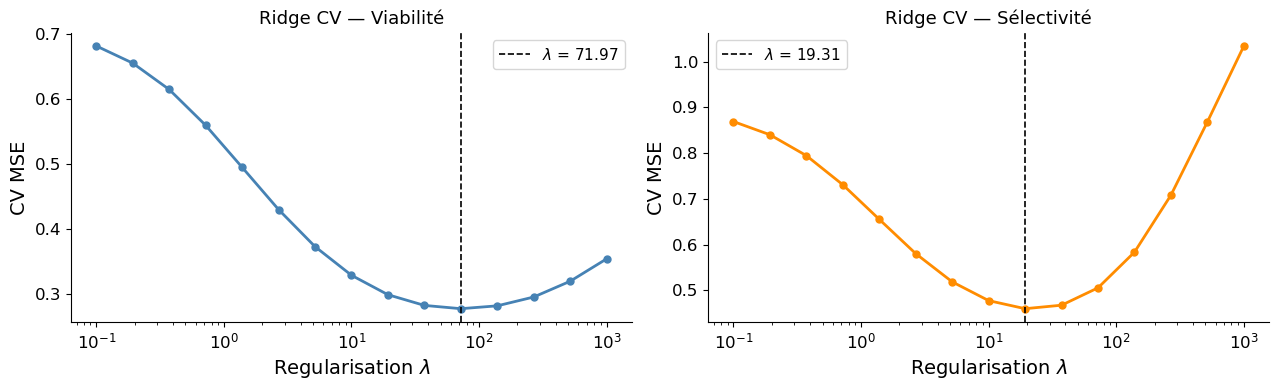

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mse, lam_best, label, color in [
    (axes[0], cv_mse_viab, lam_best_viab, 'Viabilité',   'steelblue'),
    (axes[1], cv_mse_sel,  lam_best_sel,  'Sélectivité', 'darkorange'),
]:
    ax.semilogx(lambdas, mse, color=color, lw=2, marker='o', ms=5)
    ax.axvline(lam_best, color='k', linestyle='--', lw=1.2,
               label=f'$\\lambda$ = {lam_best:.2f}')
    ax.set_xlabel('Regularisation $\\lambda$', fontsize=14)
    ax.set_ylabel('CV MSE', fontsize=14)
    ax.set_title(f'Ridge CV — {label}', fontsize=13)
    ax.legend(fontsize=11)
    ax.tick_params(labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [24]:
print("Fitting viability Potts model...")
F_viab_hat, J_viab_hat = fit_weights_potts(X_viab, y_viab_obs, T_viab, lam=lam_best_viab)

print("Fitting selectivity Potts model...")
F_sel_hat, J_sel_hat = fit_weights_potts(X_sel_feat, y_sel_obs, T_sel, lam=lam_best_sel)

v_hat = calculate_potts_scores(sequences, F_viab_hat, J_viab_hat)
s_hat = calculate_potts_scores(sequences, F_sel_hat,  J_sel_hat)

print(f"\nViability   Pearson r (scores)  : {pearson(viability_scores_GT, v_hat):.4f}")
print(f"Viability   Pearson r (F weights): {pearson(np.array(F_viab_GT).ravel(), np.array(F_viab_hat).ravel()):.4f}")
print(f"Selectivity Pearson r (scores)   : {pearson(selectivity_scores_GT, s_hat):.4f}")
print(f"Selectivity Pearson r (F weights): {pearson(np.array(F_sel_GT).ravel(), np.array(F_sel_hat).ravel()):.4f}")


Fitting viability Potts model...
Fitting selectivity Potts model...

Viability   Pearson r (scores)  : 0.9308
Viability   Pearson r (F weights): 0.9388
Selectivity Pearson r (scores)   : 0.9152
Selectivity Pearson r (F weights): 0.9342


## 7. Weight recovery: $F$ and $J$

### 7.1 Single-site weights $\hat{F}$ vs $F_{\text{GT}}$


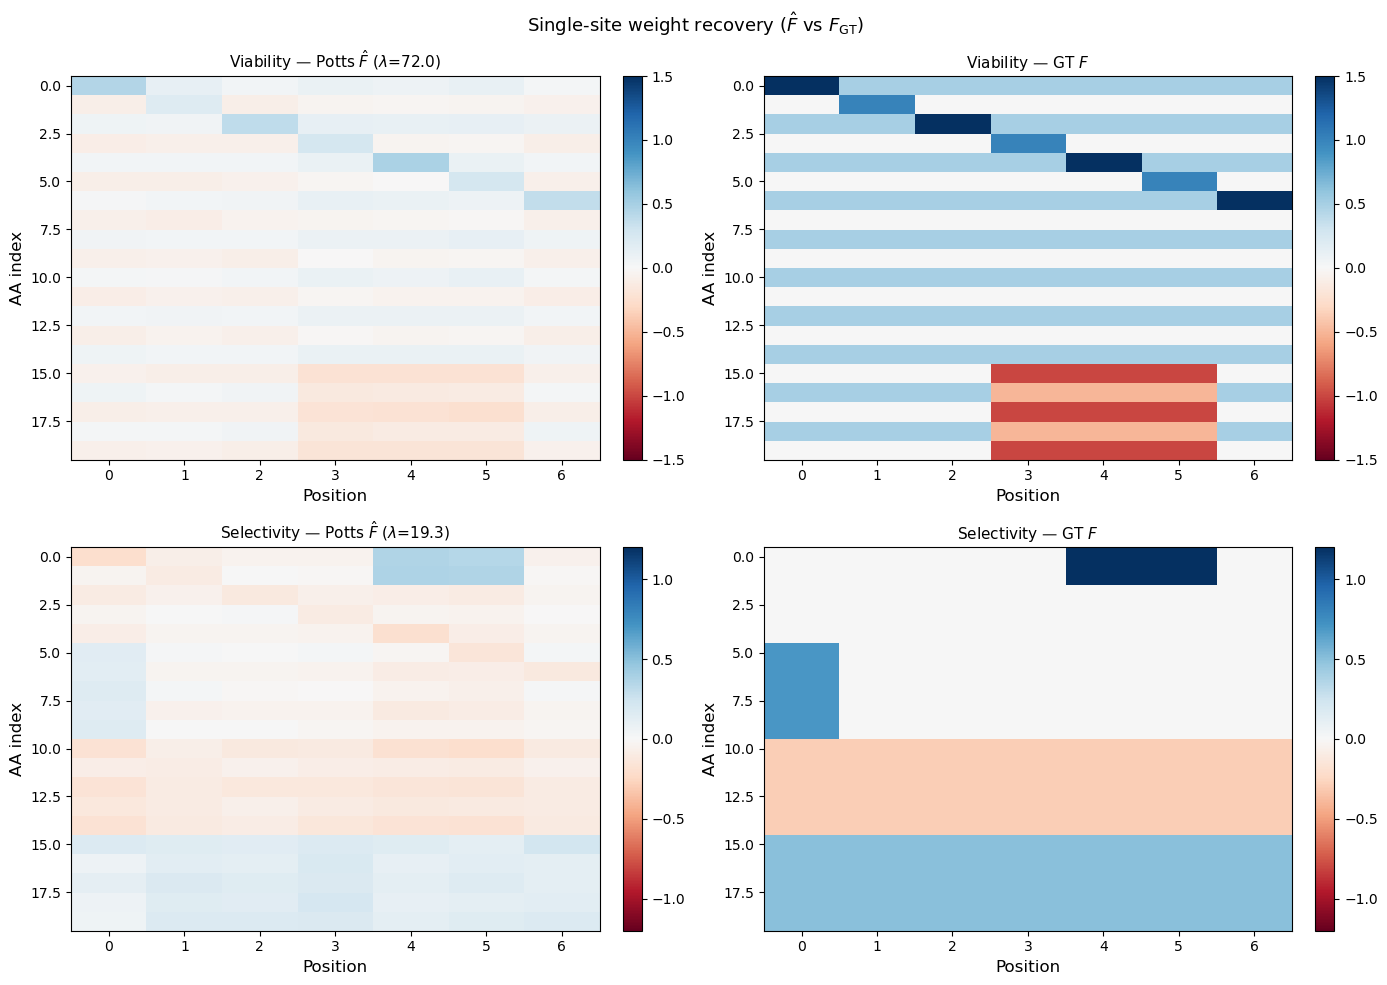

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (F_gt, F_hat, label) in enumerate([
    (F_viab_GT, F_viab_hat, 'Viability'),
    (F_sel_GT,  F_sel_hat,  'Selectivity'),
]):
    vmax = float(jnp.abs(jnp.stack([F_gt, F_hat])).max())
    for col, (data, title) in enumerate([
        (F_hat, f'{label} — Potts $\\hat{{F}}$ ($\\lambda$={lam_best_viab if row==0 else lam_best_sel:.1f})'),
        (F_gt,  f'{label} — GT $F$'),
    ]):
        ax = axes[row, col]
        im = ax.imshow(np.array(data), cmap='RdBu', aspect='auto', vmin=-vmax, vmax=vmax)
        ax.set_xlabel('Position', fontsize=12)
        ax.set_ylabel('AA index', fontsize=12)
        ax.set_title(title, fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Single-site weight recovery ($\\hat{F}$ vs $F_{\\mathrm{GT}}$)', fontsize=13)
plt.tight_layout()
plt.show()


### 7.2 Pairwise couplings $\hat{J}$ vs $J_{\text{GT}}$

We compare the GT and recovered $J[i,j]$ matrices (20×20 each) for all non-zero interaction pairs.  
Zero GT blocks are shown for context (recovered values should be close to zero there).


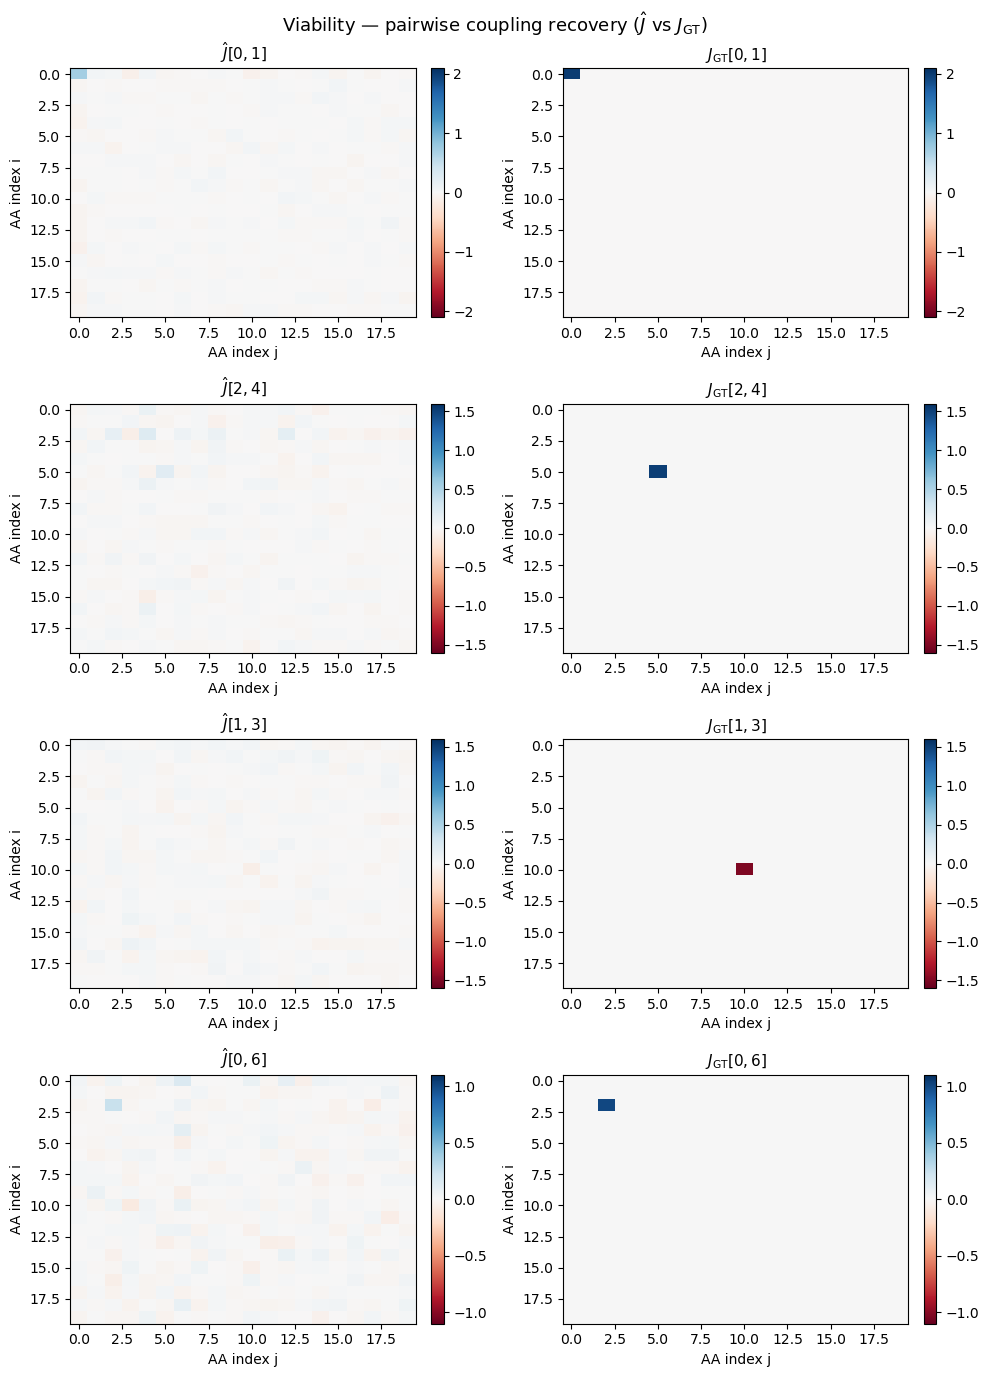

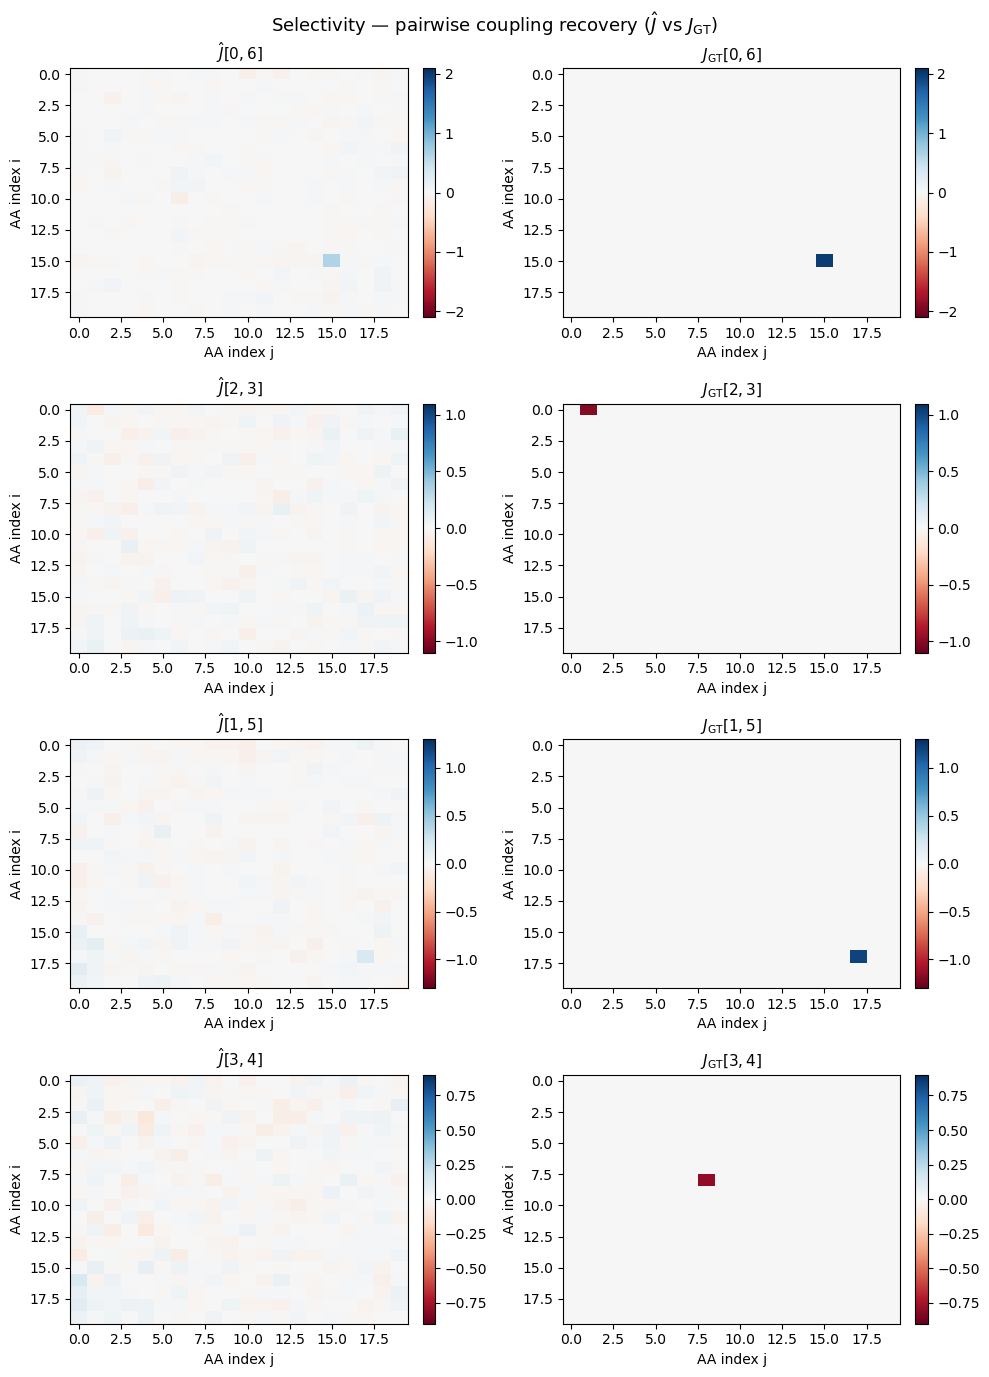

In [26]:
# Non-zero pairs from GT
gt_pairs_viab = [(0,1), (2,4), (1,3), (0,6)]
gt_pairs_sel  = [(0,6), (2,3), (1,5), (3,4)]

for label, J_gt, J_hat, pairs in [
    ('Viability',   J_viab_GT, J_viab_hat, gt_pairs_viab),
    ('Selectivity', J_sel_GT,  J_sel_hat,  gt_pairs_sel),
]:
    fig, axes = plt.subplots(4, 2, figsize=(10, 14))
    for k, (i, j) in enumerate(pairs):
        vmax = max(float(jnp.abs(J_gt[i, j]).max()), float(jnp.abs(J_hat[i, j]).max())) + 0.1
        for col, (data, title) in enumerate([
            (np.array(J_hat[i, j]), f'$\\hat{{J}}[{i},{j}]$'),
            (np.array(J_gt[i, j]),  f'$J_{{\\mathrm{{GT}}}}[{i},{j}]$'),
        ]):
            ax = axes[k, col]
            im = ax.imshow(data, cmap='RdBu', aspect='auto', vmin=-vmax, vmax=vmax)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('AA index j', fontsize=10)
            ax.set_ylabel('AA index i', fontsize=10)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(f'{label} — pairwise coupling recovery ($\\hat{{J}}$ vs $J_{{\\mathrm{{GT}}}}$)', fontsize=13)
    plt.tight_layout()
    plt.show()


## 8. GT scores vs predicted scores

Scatter plot of $E^{\text{Potts}}_{\text{GT}}(s)$ vs $\hat{E}^{\text{Potts}}(s)$ for all sequences,  
with top-10% sequences highlighted (same visualisation as the linear notebooks).


Precision@10% (combined score, Potts) : 0.7189


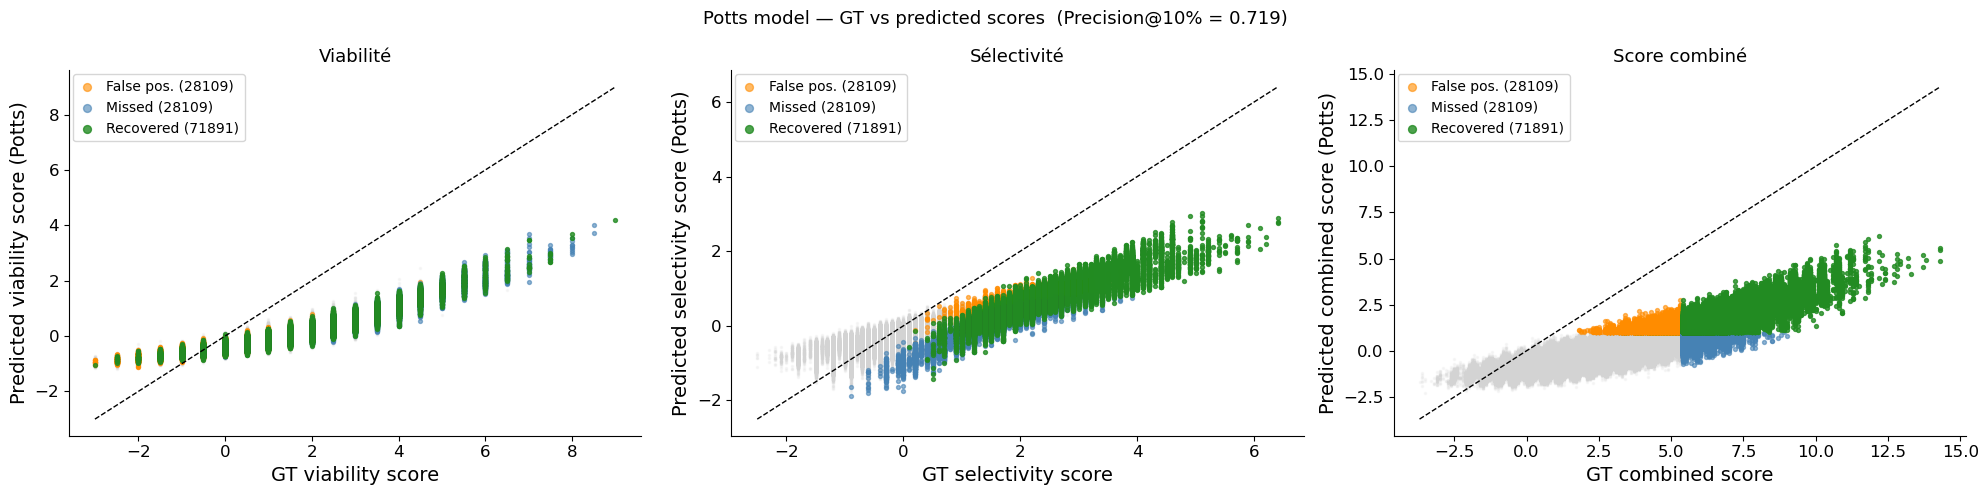

In [ ]:
v_gt_arr = np.array(viability_scores_GT)
s_gt_arr = np.array(selectivity_scores_GT)
v_hat_arr = np.array(v_hat)
s_hat_arr = np.array(s_hat)

combined_gt  = v_gt_arr  / T_viab + s_gt_arr  / T_sel
combined_hat = v_hat_arr / T_viab + s_hat_arr / T_sel

k10      = int(num_sequences * 0.10)
top_gt   = set(np.argsort(-combined_gt)[:k10])
top_hat  = set(np.argsort(-combined_hat)[:k10])
both     = np.array(sorted(top_gt & top_hat))
only_gt  = np.array(sorted(top_gt  - top_hat))
only_hat = np.array(sorted(top_hat - top_gt))
rest     = np.array(sorted(set(range(num_sequences)) - top_gt - top_hat))

p10 = precision_at_k(combined_gt, combined_hat, k_frac=0.10)
print(f"Precision@10% (combined score, Potts) : {p10:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, gt_scores, hat_scores, title, xlabel, ylabel in [
    (axes[0], v_gt_arr,    v_hat_arr,    'Viabilité',
     'GT viability score', 'Predicted viability score (Potts)'),
    (axes[1], s_gt_arr,    s_hat_arr,    'Sélectivité',
     'GT selectivity score', 'Predicted selectivity score (Potts)'),
    (axes[2], combined_gt, combined_hat, 'Score combiné',
     'GT combined score', 'Predicted combined score (Potts)'),
]:
    ax.scatter(gt_scores[rest],     hat_scores[rest],     s=2,  alpha=0.15, color='lightgray')
    ax.scatter(gt_scores[only_hat], hat_scores[only_hat], s=8,  alpha=0.6,  color='darkorange',
               label=f'False pos. ({len(only_hat)})')
    ax.scatter(gt_scores[only_gt],  hat_scores[only_gt],  s=8,  alpha=0.6,  color='steelblue',
               label=f'Missed ({len(only_gt)})')
    ax.scatter(gt_scores[both],     hat_scores[both],     s=8,  alpha=0.8,  color='forestgreen',
               label=f'Recovered ({len(both)})')
    lo, hi = gt_scores.min(), gt_scores.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=13)
    ax.tick_params(labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=10, markerscale=2, borderaxespad=0.3,
              borderpad=0.4, handlelength=1.2)

plt.suptitle(f'Potts model — GT vs predicted scores  (Precision@10% = {p10:.3f})', fontsize=13)
plt.tight_layout()
plt.show()


In [28]:
fracs = [0.01, 0.05, 0.10, 0.20]
print('  Top-%    Precision@k   (random baseline = top-%)')
print('  ──────────────────────────────────────────────────')
for frac in fracs:
    p = precision_at_k(combined_gt, combined_hat, k_frac=frac)
    print(f'  Top {int(frac*100):3d}%      {p:.3f}      (baseline: {frac:.2f})')


  Top-%    Precision@k   (random baseline = top-%)
  ──────────────────────────────────────────────────
  Top   1%      0.647      (baseline: 0.01)
  Top   5%      0.696      (baseline: 0.05)
  Top  10%      0.719      (baseline: 0.10)
  Top  20%      0.746      (baseline: 0.20)


## 9. Effect of noise $\varepsilon$ on Potts recovery

Same study as for the linear models: vary $\varepsilon \in \{0,\, \varepsilon_{\max}/100,\, \varepsilon_{\max}/10,\, \varepsilon_{\max}/3\}$  
and refit the Potts model (with CV) at each noise level.  
We track the top-10% recovery (Precision@10%) on viability scores.


  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=0.000  lam_CV=81.11
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=0.090  lam_CV=81.11
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=0.900  lam_CV=81.11
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=3.000  lam_CV=432.88


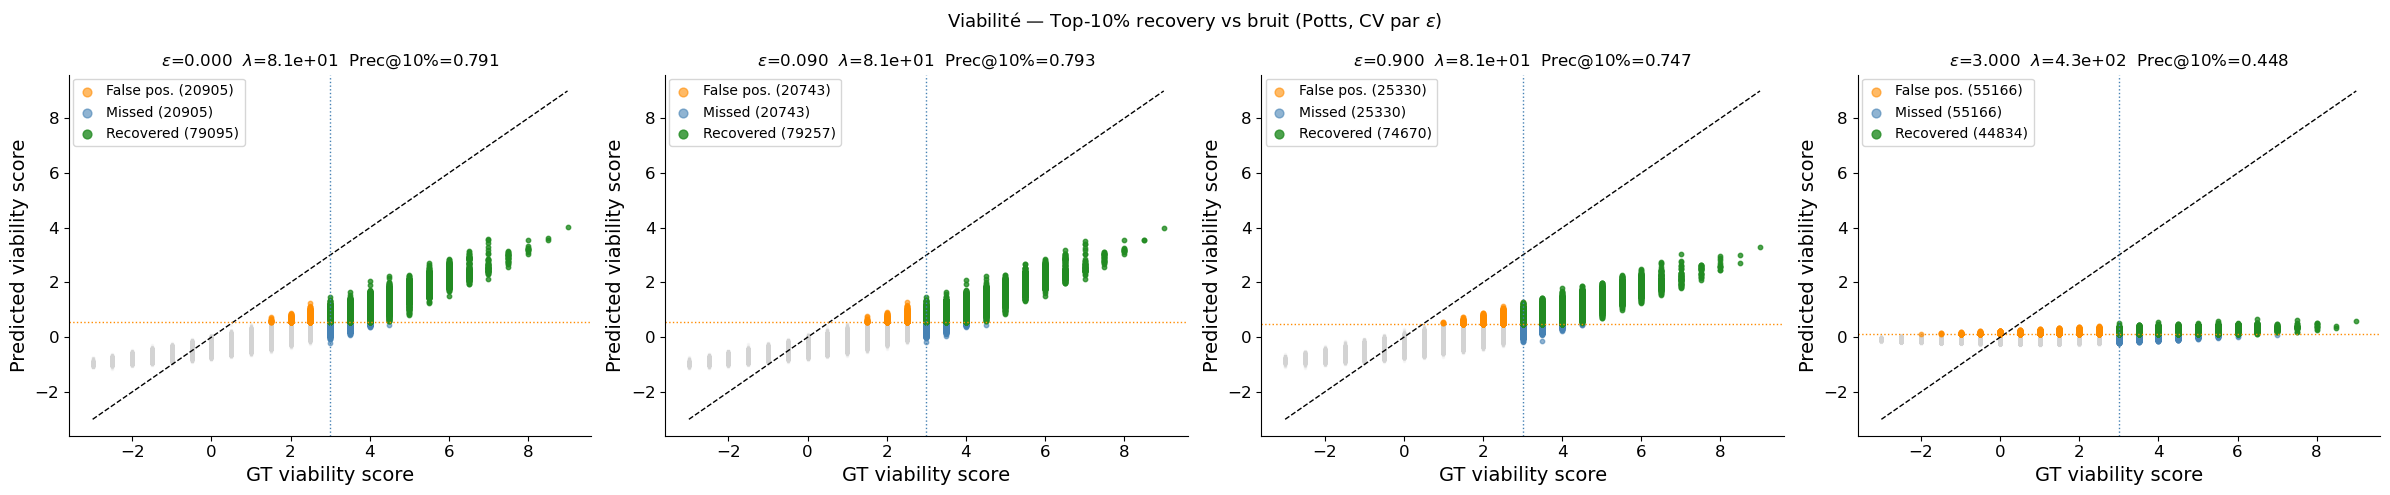

In [ ]:
_eps_pc       = 0.5
_lam_fixed    = lam_best_viab   # reuse best lambda from noiseless fit
_kf_eps       = KFold(n_splits=5, shuffle=True, random_state=0)
_lambdas_sw   = np.logspace(-1, 3, 12)

v_gt_e = np.array(viability_scores_GT)
max_vgt = float(v_gt_e.max())
eps_vals = [0.0, max_vgt / 100, max_vgt / 10, max_vgt / 3]

key_noise = jax.random.key(77)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, eps_val in zip(axes, eps_vals):
    kn1, kn2, kn3, kn4, kn5, kn6 = jax.random.split(key_noise, 6)

    # Protocol with this epsilon
    x1_e     = jax.random.poisson(kn1, lambda0 / jnp.sum(lambda0) * N1).astype(jnp.float32)
    caps_e   = produce_capsids(x1_e, viability_scores_GT, eps_val, alpha, rho, T_viab, kn2).astype(jnp.float32)
    l1p_e    = jax.random.poisson(kn3, caps_e / (jnp.sum(caps_e)+1e-9) * D).astype(jnp.float32)

    n0n_e    = n0 / jnp.sum(n0) * jnp.sum(l1p_e)
    y_ve     = np.array(jnp.log((l1p_e + _eps_pc) / (n0n_e + _eps_pc)))
    mask_ve  = np.array(l1p_e > 0)

    X_ve = build_potts_features(np.array(sequences[mask_ve]))
    cv_ve = ridge_cv_mse_potts(X_ve, y_ve[mask_ve], _lambdas_sw, _kf_eps)
    lam_e = _lambdas_sw[np.argmin(cv_ve)]
    print(f"eps={eps_val:.5f}  lam_CV={lam_e:.2f}", flush=True)

    F_ve, J_ve = fit_weights_potts(X_ve, y_ve[mask_ve], T_viab, lam=lam_e)
    vh_e = np.array(calculate_potts_scores(sequences, F_ve, J_ve))

    k10       = int(num_sequences * 0.10)
    top_gt_v  = set(np.argsort(-v_gt_e)[:k10])
    top_hat_v = set(np.argsort(-vh_e)[:k10])
    both_v    = np.array(sorted(top_gt_v & top_hat_v))
    only_gt_v = np.array(sorted(top_gt_v  - top_hat_v))
    only_hv   = np.array(sorted(top_hat_v - top_gt_v))
    rest_v    = np.array(sorted(set(range(num_sequences)) - top_gt_v - top_hat_v))

    ax.scatter(v_gt_e[rest_v],    vh_e[rest_v],    s=2,  alpha=0.15, color='lightgray')
    ax.scatter(v_gt_e[only_hv],   vh_e[only_hv],   s=10, alpha=0.6,  color='darkorange',
               label=f'False pos. ({len(only_hv)})')
    ax.scatter(v_gt_e[only_gt_v], vh_e[only_gt_v], s=10, alpha=0.6,  color='steelblue',
               label=f'Missed ({len(only_gt_v)})')
    ax.scatter(v_gt_e[both_v],    vh_e[both_v],    s=10, alpha=0.8,  color='forestgreen',
               label=f'Recovered ({len(both_v)})')
    lo, hi = v_gt_e.min(), v_gt_e.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.axvline(np.sort(v_gt_e)[-k10], color='steelblue',  linestyle=':', lw=1)
    ax.axhline(np.sort(vh_e)[-k10],   color='darkorange', linestyle=':', lw=1)
    p10 = precision_at_k(v_gt_e, vh_e, k_frac=0.10)
    ax.set_xlabel('GT viability score', fontsize=14)
    ax.set_ylabel('Predicted viability score', fontsize=14)
    ax.set_title(f'$\\varepsilon$={eps_val:.3f}  $\\lambda$={lam_e:.1e}  Prec@10%={p10:.3f}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=10, markerscale=2, borderaxespad=0.3, borderpad=0.4, handlelength=1.2)

plt.suptitle('Viabilité — Top-10% recovery vs bruit (Potts, CV par $\\varepsilon$)', fontsize=13)
plt.tight_layout()
plt.show()


  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=0.000  lam_CV=81.11
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=0.090  lam_CV=81.11
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=0.900  lam_CV=81.11
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
eps=3.000  lam_CV=432.88

## 10. With random weights

In [7]:
key, key_F_viab, key_F_sel, key_J_viab, key_J_sel = jax.random.split(key, 5)

### ------- F score ------- ###
F_viab_GT = jax.random.normal(key_F_viab, shape=(num_sequences, num_positions))
F_sel_GT  = jax.random.normal(key_F_sel, shape=(num_sequences, num_positions))

### ------- Pairwise interactions J ------- ###
Interactions = [
    [i, j, a, b]
    for i in range(num_positions)
    for j in range(i + 1, num_positions)   # i < j to avoid doubling value
    for a in range(num_amino_acids)
    for b in range(num_amino_acids)
]

pair_weights_viab = jax.random.normal(key_J_viab, shape=(len(Interactions),))

J_viab_GT = make_J([
    (*ij, float(v))
    for ij, v in zip(Interactions, pair_weights_viab)
])

pair_weights_sel = jax.random.normal(key_J_sel, shape=(len(Interactions),))

J_sel_GT = make_J([
    (*ij, float(v))
    for ij, v in zip(Interactions, pair_weights_sel)
])


viability   scores : min=-24.09  max=24.41
selectivity scores : min=-25.65  max=26.36


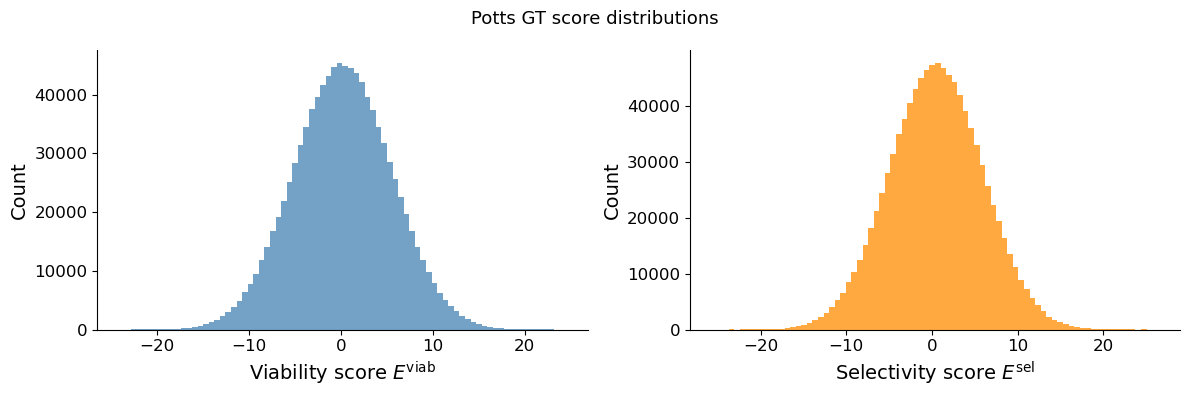

In [10]:
viability_scores_GT   = calculate_potts_scores(sequences, F_viab_GT, J_viab_GT)
selectivity_scores_GT = calculate_potts_scores(sequences, F_sel_GT,  J_sel_GT)

print(f"viability   scores : min={float(viability_scores_GT.min()):.2f}  max={float(viability_scores_GT.max()):.2f}")
print(f"selectivity scores : min={float(selectivity_scores_GT.min()):.2f}  max={float(selectivity_scores_GT.max()):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scores, label, color in [
    (axes[0], viability_scores_GT,   'Viability score $E^{\\mathrm{viab}}$',   'steelblue'),
    (axes[1], selectivity_scores_GT, 'Selectivity score $E^{\\mathrm{sel}}$', 'darkorange'),
]:
    ax.hist(np.array(scores), bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.set_xlabel(label, fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Potts GT score distributions', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
lambda0, capsids, lambda1p, n2 = protocol(n0=n0, sequences=sequences,
                                          viability_weights=
                                )